In [11]:
# 
nums = (i for i in range(2**31))

def ishappy(num):
        def get_next(n):
            total_sum = 0
            while n > 0:
                n, digit = divmod(n, 10)
                total_sum += digit**2
            return total_sum

        seen = set()
        while num != 1 and num not in seen:
            seen.add(num)
            num = get_next(num)

        return num == 1
ishappy(19)

True

In [12]:
import itertools
import matplotlib.pyplot as plt
def get_happy_path(num):
    """Returns the full sequence of values a number takes."""
    def get_next(n):
        total_sum = 0
        while n > 0:
            n, digit = divmod(n, 10)
            total_sum += digit**2
        return total_sum

    path = [num]
    seen = set()
    while num != 1 and num not in seen:
        seen.add(num)
        num = get_next(num)
        path.append(num)
    return path, num == 1

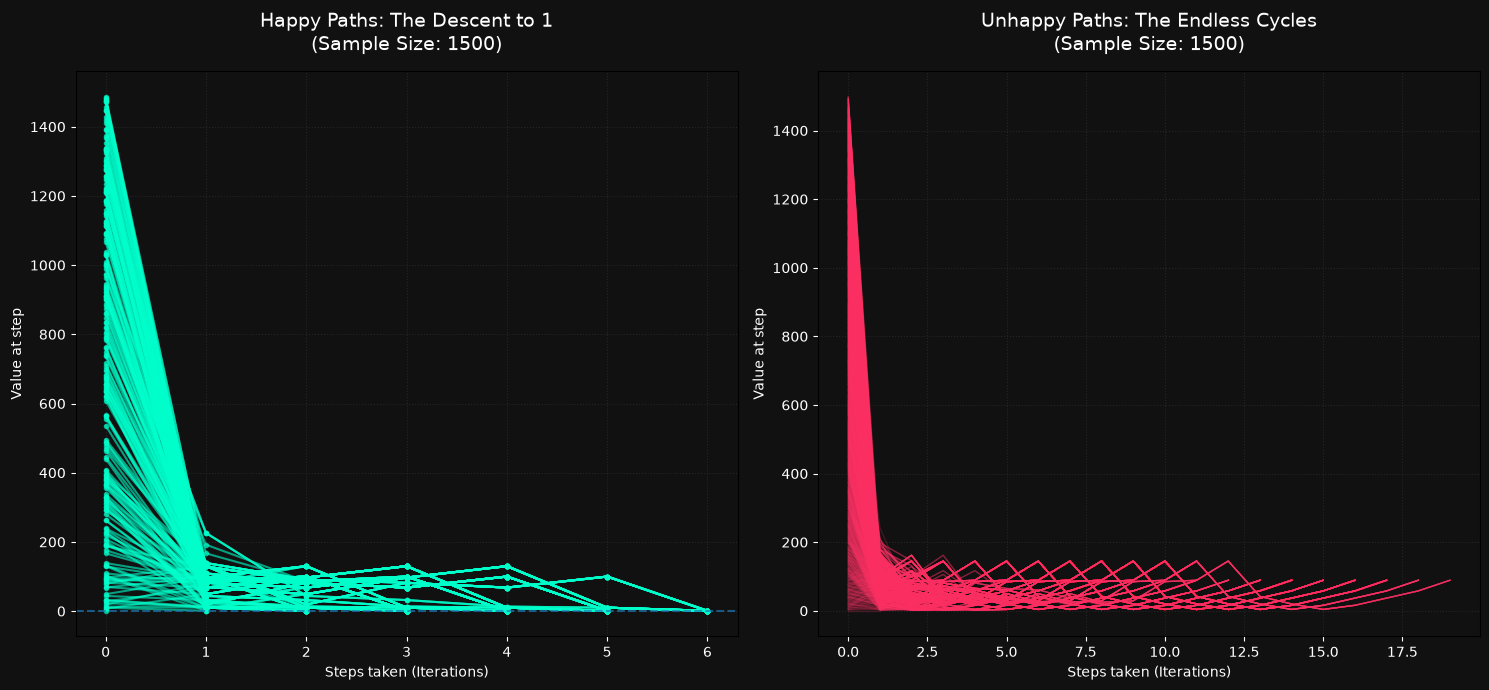

In [13]:
# 2. Extract paths for the first 150 numbers
sample_size = 1500
sample_nums = list(itertools.islice(nums, sample_size))

# 3. Initialize separate figures for a clean layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), facecolor='#111111')

# Custom dark-theme styling
for ax in (ax1, ax2):
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white', labelsize=10)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.grid(True, color='#333333', linestyle=':', alpha=0.6)

# 4. Plot paths independently
for x in sample_nums:
    path, is_happy = get_happy_path(x)
    steps = list(range(len(path)))
    
    if is_happy:
        # Happy paths fade down gracefully to 1
        ax1.plot(steps, path, color='#00FFCC', alpha=0.6, linewidth=1.5, marker='o', markersize=3)
    else:
        # Unhappy paths spiral into the chaotic cycle pattern
        ax2.plot(steps, path, color='#FF3366', alpha=0.2, linewidth=1)

# 5. Accentuate the final destination states
ax1.axhline(1, linestyle='--', alpha=0.7, label='Happy Ending (1)')
ax1.set_title(f"Happy Paths: The Descent to 1\n(Sample Size: {sample_size})", fontsize=14, pad=15)
ax1.set_xlabel("Steps taken (Iterations)")
ax1.set_ylabel("Value at step")

ax2.set_title(f"Unhappy Paths: The Endless Cycles\n(Sample Size: {sample_size})", fontsize=14, pad=15)
ax2.set_xlabel("Steps taken (Iterations)")
ax2.set_ylabel("Value at step")

plt.tight_layout()
plt.show()